In [ ]:
import pandas as pd

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
test_save_name = 'test_rows.csv'
train_save_name = 'train_rows.csv'
save_loc = './drive/MyDrive/bert-brains/'

In [ ]:
res_df = pd.read_csv(save_loc+test_save_name)
res_df = res_df[res_df['brain_key'].isin([16, 84, 106, 111, 132, 133, 134])]
res_df

,epoch,batch_size,rsa_reg_term,mse_loss,rsa_loss,reg_strength,test_correlation,testing_regime,brain_key,brain_sim_name,sentence_embedding_size,model_name,sts_corr,sts_p,lr,ex_name
0,0,5,0.940475,0.021968,0.113819,0.1,0.205451,same_subject,16,best_36_parcels,128,bert-base-uncased,0.126230,9.370000e-07,0.0001,experiment_batch_size_5
1,1,5,0.946590,0.016633,0.109628,0.1,0.185241,same_subject,16,best_36_parcels,128,bert-base-uncased,0.112580,1.240000e-05,0.0001,experiment_batch_size_5
2,2,5,0.948785,0.030502,0.122330,0.1,0.286479,same_subject,16,best_36_parcels,128,bert-base-uncased,0.153154,2.490000e-09,0.0001,experiment_batch_size_5
3,3,5,1.023303,0.020870,0.121113,0.1,0.395606,same_subject,16,best_36_parcels,128,bert-base-uncased,0.169228,4.210000e-11,0.0001,experiment_batch_size_5
4,4,5,0.874480,0.026066,0.110907,0.1,0.173348,same_subject,16,best_36_parcels,128,bert-base-uncased,0.091060,4.137841e-04,0.0001,experiment_batch_size_5
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
915,5,5,0.980188,0.002966,0.002966,0.0,0.188165,same_subject,134,best_36_parcels,128,textattack/bert-base-uncased-STS-B,0.179557,2.462272e-12,0.0001,experiment_sts_bert
916,6,5,0.916261,0.002913,0.002913,0.0,0.143316,same_subject,134,best_36_parcels,128,textattack/bert-base-uncased-STS-B,0.173981,1.165296e-11,0.0001,experiment_sts_bert
917,7,5,0.960369,0.004045,0.004045,0.0,0.177708,same_subject,134,best_36_parcels,128,textattack/bert-base-uncased-STS-B,0.193638,3.877843e-14,0.0001,experiment_sts_bert
918,8,5,0.965675,0.002413,0.002413,0.0,0.295989,same_subject,134,best_36_parcels,128,textattack/bert-base-uncased-STS-B,0.211923,1.083201e-16,0.0001,experiment_sts_bert


In [ ]:
res_df.ex_name.unique()

array(['experiment_batch_size_5', 'experiment_batch_size_10',
       'experiment_hidden_size_big', 'experiment_hidden_size_small',
       'experiment_lr', 'experiment_other_subject',
       'experiment_parcels_all', 'experiment_parcels_rand',
       'experiment_reg_strength', 'experiment_no_reg',
       'experiment_sts_bert'], dtype=object)

In [ ]:
experiments = [
    {"name": "Experiment 1: Regularisation", "conditions": ["experiment_batch_size_5", "experiment_no_reg"]},
    {"name": "Experiment 2: Regularisation Strength", "conditions": ["experiment_batch_size_5", "experiment_reg_strength"]},
    {"name": "Experiment 3: Regularisation Source Hidden Size", "conditions": ["experiment_batch_size_5", "experiment_hidden_size_small", "experiment_hidden_size_big"]},
    {"name": "Experiment 4: Batch Size", "conditions": ["experiment_batch_size_5", "experiment_batch_size_10"]},
    {"name": "Experiment 5: Learning Rate Magnitude", "conditions": ["experiment_batch_size_5", "experiment_lr"]},
    {"name": "Experiment 6: Parcellation Strategy", "conditions": ["experiment_batch_size_5", "experiment_parcels_rand", "experiment_parcels_all"]},
    {"name": "Experiment 7: Generalisation across Brains", "conditions": ["experiment_batch_size_5", "experiment_other_subject"]},
    {"name": "Experiment 8: Fine-tuning STS-BERT", "conditions": ["experiment_batch_size_5", "experiment_sts_bert"]},
    {"name": "Experiment 9: RSR and STS-Benchmark Evaluation", "conditions": ["experiment_batch_size_5"]},
]

In [ ]:
import seaborn as sns
import os
import matplotlib.pyplot as plt

## Experiment 1:

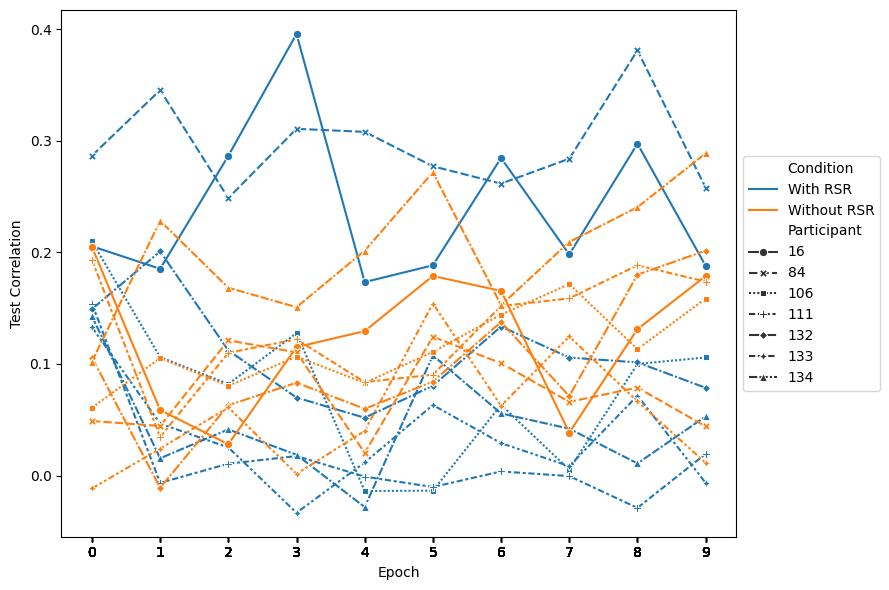

In [ ]:
exp_data = res_df[res_df['ex_name'].isin(experiments[0]["conditions"])].copy()

exp_data.loc[exp_data['ex_name'] == "experiment_batch_size_5", 'ex_name'] = "With RSR"
exp_data.loc[exp_data['ex_name'] == "experiment_no_reg", 'ex_name'] = "Without RSR"

exp_data = exp_data.rename(columns={"ex_name": "Condition"})
exp_data = exp_data.rename(columns={"brain_key": "Participant"})
# Assuming you have your exp_data DataFrame

# Create a larger figure
plt.figure(figsize=(9, 6))  # Adjust the width and height as needed

# Create the line plot with renamed labels and markers
ax =sns.lineplot(
    data=exp_data,
    y="test_correlation",
    x="epoch",  # No renaming needed for x-axis in Seaborn
    style="Participant",
    hue="Condition",
    markers=True,  # Add markers at each data point
    legend="full"  # Adjust legend placement (optional)
)

# Customize axis labels (optional)
plt.xlabel("Epoch")
plt.ylabel("Test Correlation")
plt.title("")

ax.set(xticks=exp_data.epoch.values)

# Rotate x-axis labels for better readability (optional)
# plt.xticks(rotation=45)  # Adjust rotation angle if needed

sns.move_legend(ax, "center left", bbox_to_anchor=(1, 0.5))

# Show the plot
plt.tight_layout()  # Adjust spacing to avoid clipping labels or legend

os.makedirs(os.path.join(save_loc, "results"), exist_ok=True)  # Using os.makedirs for directory creation

# Save the plot in three formats
for filetype in ['png', 'pdf', 'eps']:
    filename = os.path.join(save_loc, "results", f"experiment_one.{filetype}")
    plt.savefig(filename, format=filetype, dpi=300, bbox_inches='tight')

plt.show()


In [ ]:
import os

# Experiment 2

In [ ]:
exp_data = res_df[res_df['ex_name'].isin(experiments[1]["conditions"])].copy()
exp_data.ex_name.unique()

array(['experiment_batch_size_5', 'experiment_reg_strength'], dtype=object)

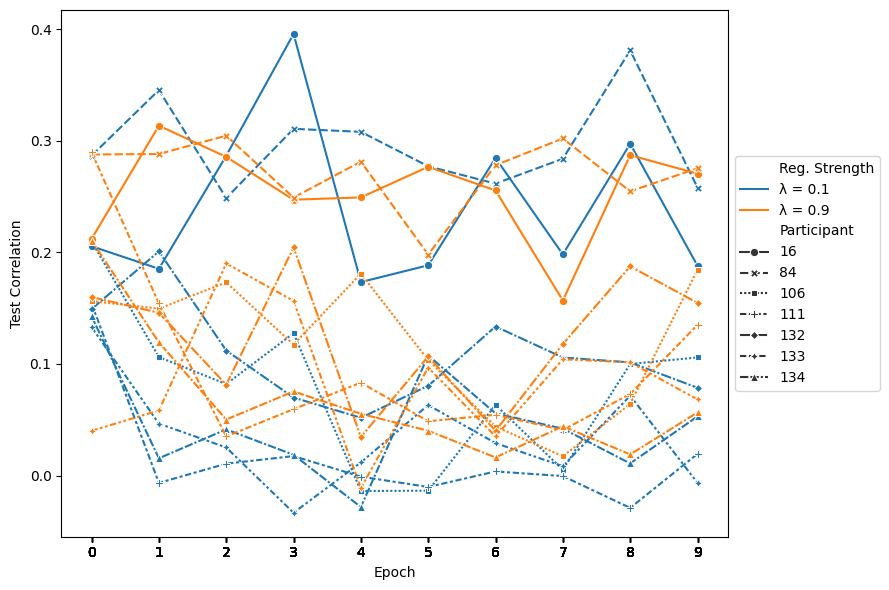

In [ ]:
exp_data = res_df[res_df['ex_name'].isin(experiments[1]["conditions"])].copy()

exp_data.loc[exp_data['ex_name'] == "experiment_batch_size_5", 'ex_name'] = "λ = 0.1"
exp_data.loc[exp_data['ex_name'] == "experiment_reg_strength", 'ex_name'] = "λ = 0.9"

exp_data = exp_data.rename(columns={"ex_name": "Reg. Strength"})
exp_data = exp_data.rename(columns={"brain_key": "Participant"})

# Assuming you have your exp_data DataFrame

# Create a larger figure
plt.figure(figsize=(9, 6))  # Adjust the width and height as needed

# Create the line plot with renamed labels and markers
ax =sns.lineplot(
    data=exp_data,
    y="test_correlation",
    x="epoch",  # No renaming needed for x-axis in Seaborn
    style="Participant",
    hue="Reg. Strength",
    markers=True,  # Add markers at each data point
    legend="full"  # Adjust legend placement (optional)
)

# Customize axis labels (optional)
plt.xlabel("Epoch")
plt.ylabel("Test Correlation")
plt.title("")

ax.set(xticks=exp_data.epoch.values)

# Rotate x-axis labels for better readability (optional)
# plt.xticks(rotation=45)  # Adjust rotation angle if needed

sns.move_legend(ax, "center left", bbox_to_anchor=(1, 0.5))

# Show the plot
plt.tight_layout()  # Adjust spacing to avoid clipping labels or legend

os.makedirs(os.path.join(save_loc, "results"), exist_ok=True)  # Using os.makedirs for directory creation

# Save the plot in three formats
for filetype in ['png', 'pdf', 'eps']:
    filename = os.path.join(save_loc, "results", f"experiment_two.{filetype}")
    plt.savefig(filename, format=filetype, dpi=300, bbox_inches='tight')

plt.show()


# Experiment 3

In [ ]:
exp_data = res_df[res_df['ex_name'].isin(experiments[2]["conditions"])].copy()
exp_data.ex_name.unique()

array(['experiment_batch_size_5', 'experiment_hidden_size_big',
       'experiment_hidden_size_small'], dtype=object)

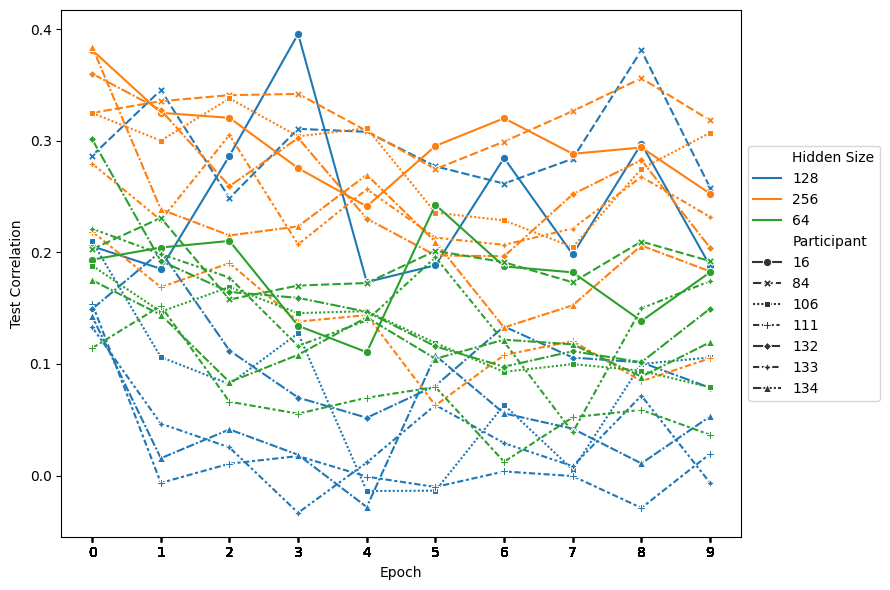

In [ ]:
exp_data = res_df[res_df['ex_name'].isin(experiments[2]["conditions"])].copy()

exp_data.loc[exp_data['ex_name'] == "experiment_batch_size_5", 'ex_name'] = "128"
exp_data.loc[exp_data['ex_name'] == "experiment_hidden_size_big", 'ex_name'] = "256"
exp_data.loc[exp_data['ex_name'] == "experiment_hidden_size_small", 'ex_name'] = "64"

exp_data = exp_data.rename(columns={"ex_name": "Hidden Size"})
exp_data = exp_data.rename(columns={"brain_key": "Participant"})

# Assuming you have your exp_data DataFrame

# Create a larger figure
plt.figure(figsize=(9, 6))  # Adjust the width and height as needed

# Create the line plot with renamed labels and markers
ax =sns.lineplot(
    data=exp_data,
    y="test_correlation",
    x="epoch",  # No renaming needed for x-axis in Seaborn
    style="Participant",
    hue="Hidden Size",
    markers=True,  # Add markers at each data point
    legend="full"  # Adjust legend placement (optional)
)

# Customize axis labels (optional)
plt.xlabel("Epoch")
plt.ylabel("Test Correlation")
plt.title("")

ax.set(xticks=exp_data.epoch.values)

# Rotate x-axis labels for better readability (optional)
# plt.xticks(rotation=45)  # Adjust rotation angle if needed

sns.move_legend(ax, "center left", bbox_to_anchor=(1, 0.5))

# Show the plot
plt.tight_layout()  # Adjust spacing to avoid clipping labels or legend

os.makedirs(os.path.join(save_loc, "results"), exist_ok=True)  # Using os.makedirs for directory creation

# Save the plot in three formats
for filetype in ['png', 'pdf', 'eps']:
    filename = os.path.join(save_loc, "results", f"experiment_three.{filetype}")
    plt.savefig(filename, format=filetype, dpi=300, bbox_inches='tight')

plt.show()


# Experiment 4

In [ ]:
exp_data = res_df[res_df['ex_name'].isin(experiments[3]["conditions"])].copy()
exp_data.ex_name.unique()

array(['experiment_batch_size_5', 'experiment_batch_size_10'],
      dtype=object)

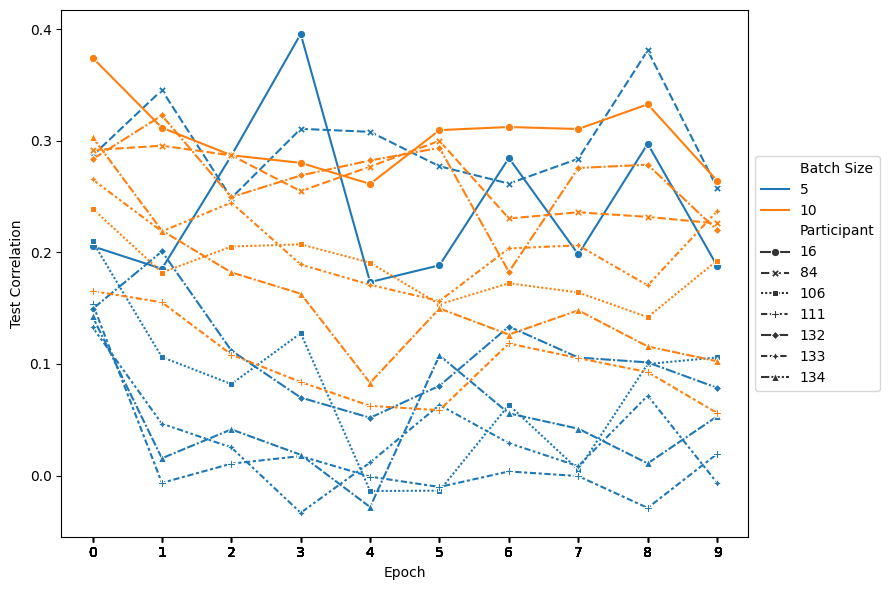

In [ ]:
exp_data = res_df[res_df['ex_name'].isin(experiments[3]["conditions"])].copy()

exp_data.loc[exp_data['ex_name'] == "experiment_batch_size_5", 'ex_name'] = "5"
exp_data.loc[exp_data['ex_name'] == "experiment_batch_size_10", 'ex_name'] = "10"

exp_data = exp_data.rename(columns={"ex_name": "Batch Size"})
exp_data = exp_data.rename(columns={"brain_key": "Participant"})

# Assuming you have your exp_data DataFrame

# Create a larger figure
plt.figure(figsize=(9, 6))  # Adjust the width and height as needed

# Create the line plot with renamed labels and markers
ax =sns.lineplot(
    data=exp_data,
    y="test_correlation",
    x="epoch",  # No renaming needed for x-axis in Seaborn
    style="Participant",
    hue="Batch Size",
    markers=True,  # Add markers at each data point
    legend="full"  # Adjust legend placement (optional)
)

# Customize axis labels (optional)
plt.xlabel("Epoch")
plt.ylabel("Test Correlation")
plt.title("")

ax.set(xticks=exp_data.epoch.values)

# Rotate x-axis labels for better readability (optional)
# plt.xticks(rotation=45)  # Adjust rotation angle if needed

sns.move_legend(ax, "center left", bbox_to_anchor=(1, 0.5))

# Show the plot
plt.tight_layout()  # Adjust spacing to avoid clipping labels or legend

os.makedirs(os.path.join(save_loc, "results"), exist_ok=True)  # Using os.makedirs for directory creation

# Save the plot in three formats
for filetype in ['png', 'pdf', 'eps']:
    filename = os.path.join(save_loc, "results", f"experiment_four.{filetype}")
    plt.savefig(filename, format=filetype, dpi=300, bbox_inches='tight')

plt.show()


# Experiment 5

In [ ]:
exp_data = res_df[res_df['ex_name'].isin(experiments[4]["conditions"])].copy()
exp_data.ex_name.unique()

array(['experiment_batch_size_5', 'experiment_lr'], dtype=object)

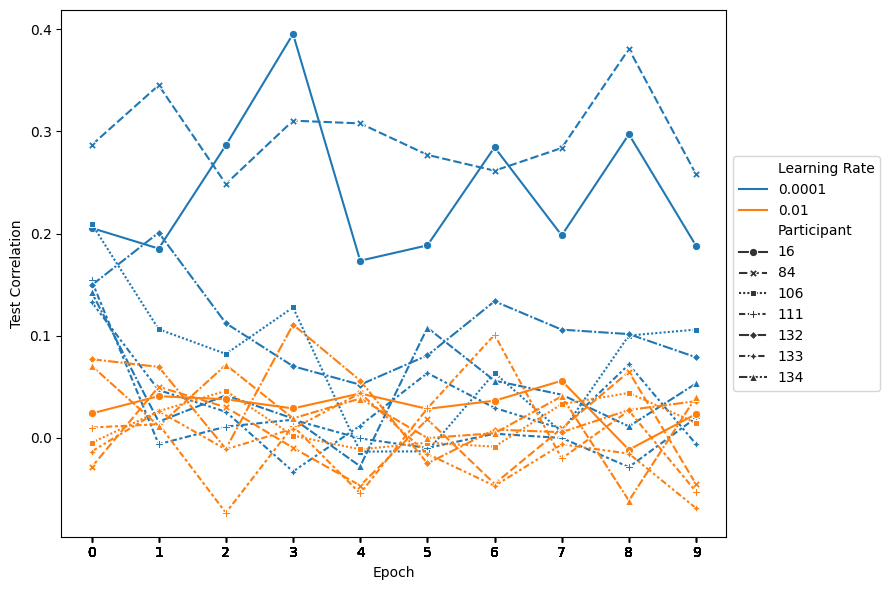

In [ ]:
exp_data = res_df[res_df['ex_name'].isin(experiments[4]["conditions"])].copy()

exp_data.loc[exp_data['ex_name'] == "experiment_batch_size_5", 'ex_name'] = "0.0001"
exp_data.loc[exp_data['ex_name'] == "experiment_lr", 'ex_name'] = "0.01"

exp_data = exp_data.rename(columns={"ex_name": "Learning Rate"})
exp_data = exp_data.rename(columns={"brain_key": "Participant"})

# Assuming you have your exp_data DataFrame

# Create a larger figure
plt.figure(figsize=(9, 6))  # Adjust the width and height as needed

# Create the line plot with renamed labels and markers
ax =sns.lineplot(
    data=exp_data,
    y="test_correlation",
    x="epoch",  # No renaming needed for x-axis in Seaborn
    style="Participant",
    hue="Learning Rate",
    markers=True,  # Add markers at each data point
    legend="full"  # Adjust legend placement (optional)
)

# Customize axis labels (optional)
plt.xlabel("Epoch")
plt.ylabel("Test Correlation")
plt.title("")

ax.set(xticks=exp_data.epoch.values)

# Rotate x-axis labels for better readability (optional)
# plt.xticks(rotation=45)  # Adjust rotation angle if needed

sns.move_legend(ax, "center left", bbox_to_anchor=(1, 0.5))

# Show the plot
plt.tight_layout()  # Adjust spacing to avoid clipping labels or legend

os.makedirs(os.path.join(save_loc, "results"), exist_ok=True)  # Using os.makedirs for directory creation

# Save the plot in three formats
for filetype in ['png', 'pdf', 'eps']:
    filename = os.path.join(save_loc, "results", f"experiment_five.{filetype}")
    plt.savefig(filename, format=filetype, dpi=300, bbox_inches='tight')

plt.show()


# Experiment 6

In [ ]:
exp_data = res_df[res_df['ex_name'].isin(experiments[5]["conditions"])].copy()
exp_data.ex_name.unique()

array(['experiment_batch_size_5', 'experiment_parcels_all',
       'experiment_parcels_rand'], dtype=object)

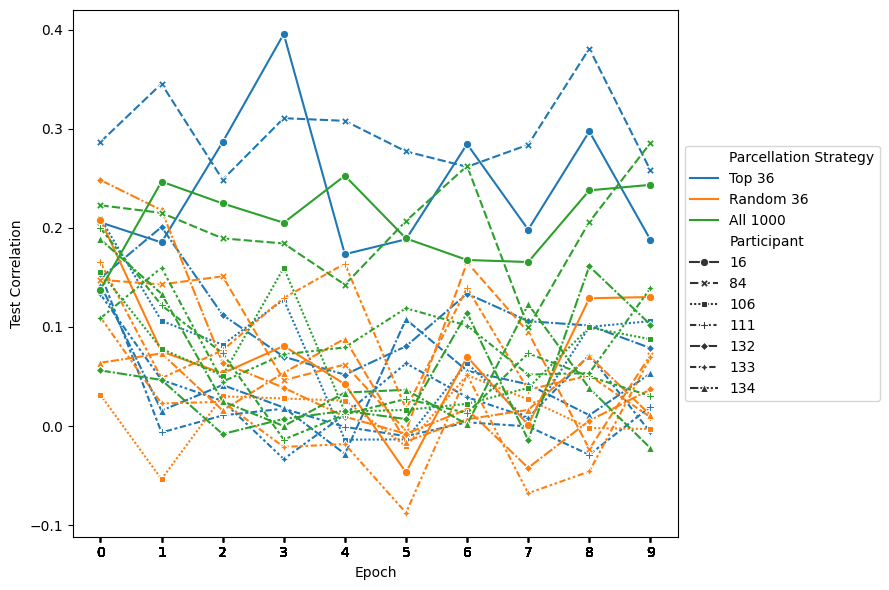

In [ ]:
exp_data = res_df[res_df['ex_name'].isin(experiments[5]["conditions"])].copy()

exp_data.loc[exp_data['ex_name'] == "experiment_batch_size_5", 'ex_name'] = "Top 36"
exp_data.loc[exp_data['ex_name'] == "experiment_parcels_all", 'ex_name'] = "Random 36"
exp_data.loc[exp_data['ex_name'] == "experiment_parcels_rand", 'ex_name'] = "All 1000"

exp_data = exp_data.rename(columns={"ex_name": "Parcellation Strategy"})
exp_data = exp_data.rename(columns={"brain_key": "Participant"})

# Assuming you have your exp_data DataFrame

# Create a larger figure
plt.figure(figsize=(9, 6))  # Adjust the width and height as needed

# Create the line plot with renamed labels and markers
ax =sns.lineplot(
    data=exp_data,
    y="test_correlation",
    x="epoch",  # No renaming needed for x-axis in Seaborn
    style="Participant",
    hue="Parcellation Strategy",
    markers=True,  # Add markers at each data point
    legend="full"  # Adjust legend placement (optional)
)

# Customize axis labels (optional)
plt.xlabel("Epoch")
plt.ylabel("Test Correlation")
plt.title("")

ax.set(xticks=exp_data.epoch.values)

# Rotate x-axis labels for better readability (optional)
# plt.xticks(rotation=45)  # Adjust rotation angle if needed

sns.move_legend(ax, "center left", bbox_to_anchor=(1, 0.5))

# Show the plot
plt.tight_layout()  # Adjust spacing to avoid clipping labels or legend

os.makedirs(os.path.join(save_loc, "results"), exist_ok=True)  # Using os.makedirs for directory creation

# Save the plot in three formats
for filetype in ['png', 'pdf', 'eps']:
    filename = os.path.join(save_loc, "results", f"experiment_six.{filetype}")
    plt.savefig(filename, format=filetype, dpi=300, bbox_inches='tight')

plt.show()


# Experiment 7

In [ ]:
exp_data = res_df[res_df['ex_name'].isin(experiments[6]["conditions"])].copy()
exp_data.ex_name.unique()

array(['experiment_batch_size_5', 'experiment_other_subject'],
      dtype=object)

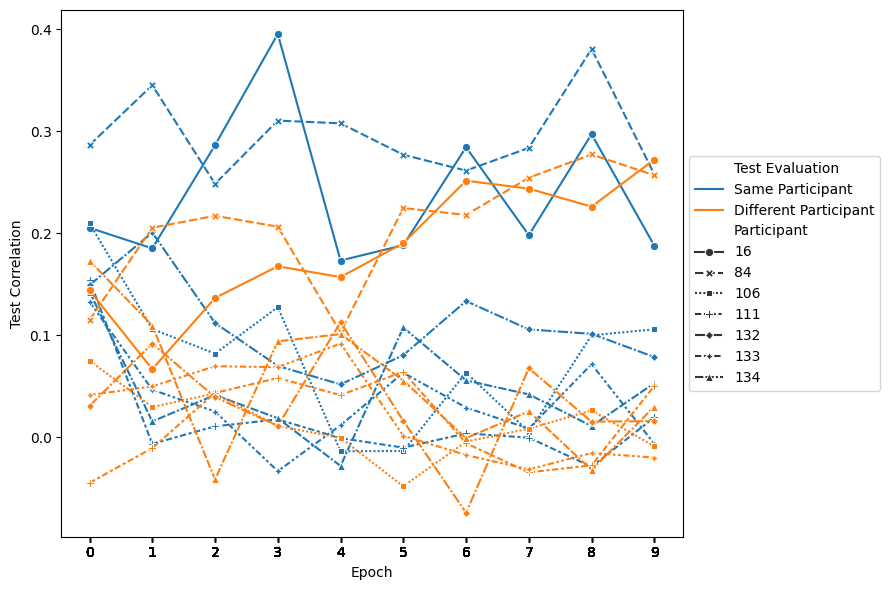

In [ ]:
exp_data = res_df[res_df['ex_name'].isin(experiments[6]["conditions"])].copy()

exp_data.loc[exp_data['ex_name'] == "experiment_batch_size_5", 'ex_name'] = "Same Participant"
exp_data.loc[exp_data['ex_name'] == "experiment_other_subject", 'ex_name'] = "Different Participant"

exp_data = exp_data.rename(columns={"ex_name": "Test Evaluation"})
exp_data = exp_data.rename(columns={"brain_key": "Participant"})

# Assuming you have your exp_data DataFrame

# Create a larger figure
plt.figure(figsize=(9, 6))  # Adjust the width and height as needed

# Create the line plot with renamed labels and markers
ax =sns.lineplot(
    data=exp_data,
    y="test_correlation",
    x="epoch",  # No renaming needed for x-axis in Seaborn
    style="Participant",
    hue="Test Evaluation",
    markers=True,  # Add markers at each data point
    legend="full"  # Adjust legend placement (optional)
)

# Customize axis labels (optional)
plt.xlabel("Epoch")
plt.ylabel("Test Correlation")
plt.title("")

ax.set(xticks=exp_data.epoch.values)

# Rotate x-axis labels for better readability (optional)
# plt.xticks(rotation=45)  # Adjust rotation angle if needed

sns.move_legend(ax, "center left", bbox_to_anchor=(1, 0.5))

# Show the plot
plt.tight_layout()  # Adjust spacing to avoid clipping labels or legend

os.makedirs(os.path.join(save_loc, "results"), exist_ok=True)  # Using os.makedirs for directory creation

# Save the plot in three formats
for filetype in ['png', 'pdf', 'eps']:
    filename = os.path.join(save_loc, "results", f"experiment_seven.{filetype}")
    plt.savefig(filename, format=filetype, dpi=300, bbox_inches='tight')

plt.show()


# Experiment 8

In [ ]:
exp_data = res_df[res_df['ex_name'].isin(experiments[7]["conditions"])].copy()
exp_data.ex_name.unique()

array(['experiment_batch_size_5', 'experiment_sts_bert'], dtype=object)

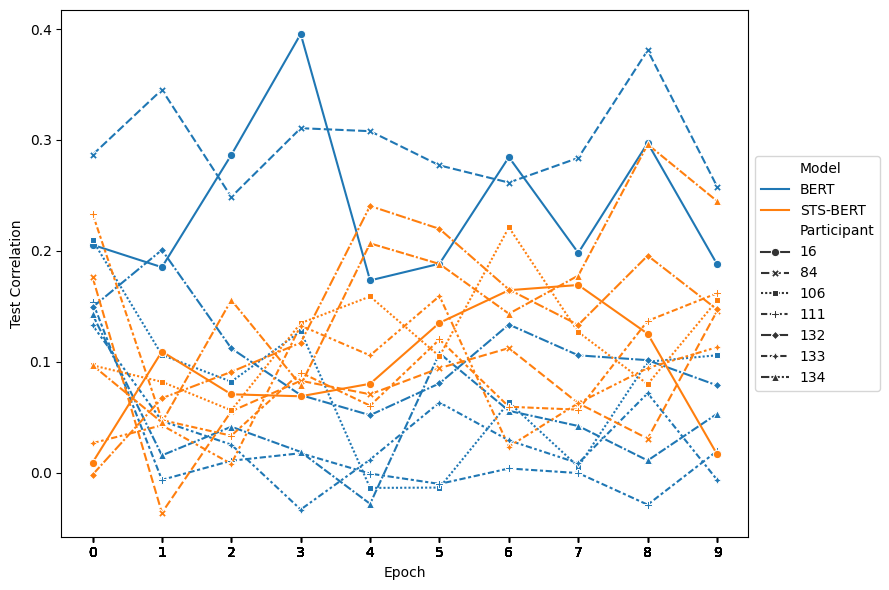

In [ ]:
exp_data = res_df[res_df['ex_name'].isin(experiments[7]["conditions"])].copy()

exp_data.loc[exp_data['ex_name'] == "experiment_batch_size_5", 'ex_name'] = "BERT"
exp_data.loc[exp_data['ex_name'] == "experiment_sts_bert", 'ex_name'] = "STS-BERT"

exp_data = exp_data.rename(columns={"ex_name": "Model"})
exp_data = exp_data.rename(columns={"brain_key": "Participant"})

# Assuming you have your exp_data DataFrame

# Create a larger figure
plt.figure(figsize=(9, 6))  # Adjust the width and height as needed

# Create the line plot with renamed labels and markers
ax =sns.lineplot(
    data=exp_data,
    y="test_correlation",
    x="epoch",  # No renaming needed for x-axis in Seaborn
    style="Participant",
    hue="Model",
    markers=True,  # Add markers at each data point
    legend="full"  # Adjust legend placement (optional)
)

# Customize axis labels (optional)
plt.xlabel("Epoch")
plt.ylabel("Test Correlation")
plt.title("")

ax.set(xticks=exp_data.epoch.values)

# Rotate x-axis labels for better readability (optional)
# plt.xticks(rotation=45)  # Adjust rotation angle if needed

sns.move_legend(ax, "center left", bbox_to_anchor=(1, 0.5))

# Show the plot
plt.tight_layout()  # Adjust spacing to avoid clipping labels or legend

os.makedirs(os.path.join(save_loc, "results"), exist_ok=True)  # Using os.makedirs for directory creation

# Save the plot in three formats
for filetype in ['png', 'pdf', 'eps']:
    filename = os.path.join(save_loc, "results", f"experiment_eight.{filetype}")
    plt.savefig(filename, format=filetype, dpi=300, bbox_inches='tight')

plt.show()


# Experiment 9

In [ ]:
res_df['regularisation'] = res_df.reg_strength>0

<ipython-input-46-c2b00407570a>:19: UserWarning: The palette list has more values (10) than needed (2), which may not be intended.
  ax = sns.scatterplot(data=exp_data,


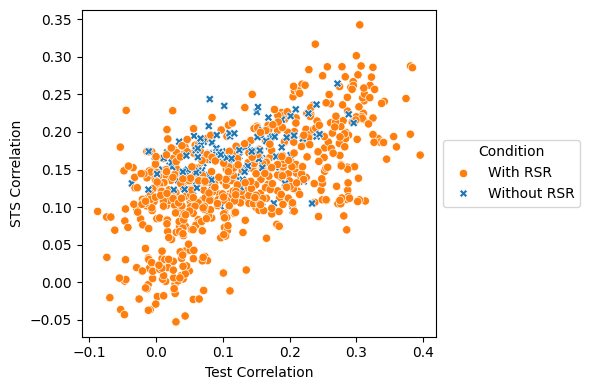

In [ ]:
exp_data = res_df.copy()
exp_data['Condition'] = exp_data.reg_strength>0

exp_data.loc[exp_data['Condition'] == True, 'Condition'] = "With RSR"
exp_data.loc[exp_data['Condition'] == False, 'Condition'] = "Without RSR"

# Reorder color palette for "Condition" hue (assuming default seaborn palette)
palette = sns.color_palette()  # Get the default palette
palette[2] = palette[0]
palette[0] = palette[1]
palette[1] = palette[2]

# Assuming you have your exp_data DataFrame

# Create a larger figure
plt.figure(figsize=(6, 4))  # Adjust the width and height as needed

# Create the line plot with renamed labels and markers
ax = sns.scatterplot(data=exp_data,
                     x="test_correlation",
                     y='sts_corr',
                     markers=True,  # Add markers at each data point
                     legend="full",  # Adjust legend placement (optional)
                     hue="Condition",
                     style="Condition",
                     palette=palette)

# Customize axis labels (optional)
plt.xlabel("Test Correlation")
plt.ylabel("STS Correlation")
plt.title("")

sns.move_legend(ax, "center left", bbox_to_anchor=(1, 0.5))

# Show the plot
plt.tight_layout()  # Adjust spacing to avoid clipping labels or legend

os.makedirs(os.path.join(save_loc, "results"), exist_ok=True)  # Using os.makedirs for directory creation

# Save the plot in three formats
for filetype in ['png', 'pdf', 'eps']:
    filename = os.path.join(save_loc, "results", f"experiment_nine.{filetype}")
    plt.savefig(filename, format=filetype, dpi=300, bbox_inches='tight')

plt.show()
